<a href="https://colab.research.google.com/github/Roan1982/Arellano/blob/main/arellanointegrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Integrador: Ciencia de Datos Aplicada
**Institución:** IFTS N° 12  
**Docente:** Matías Arellano  
**Año:** 2026

---

## 👥 Integrantes del Grupo
* **Beggi, Agostin**
* **Lopardo Cid, Luka**
* **Salas, Ezequiel**
* **Steklein, Angel**
* **Zigarra, Fernando Daniel**

---

## 📊 Etapa 1: Elección y Justificación del Dataset

### 1.1 Introducción al Proyecto
El presente trabajo integrador consiste en el desarrollo de un pipeline completo de Ciencia de Datos (*Data Pipeline*), abarcando desde la ingesta de fuentes heterogéneas hasta la implementación de un modelo predictivo supervisado de Machine Learning. El objetivo central es analizar el comportamiento de una operación minorista (*retail*) y evaluar la viabilidad de cruzar variables comerciales internas con indicadores macroeconómicos de control.

### 1.2 Origen y Fusión de las Fuentes de Datos
Para este análisis se seleccionaron y unificaron dos conjuntos de datos mediante técnicas de combinación relacional (`.merge()`):

1. **Dataset Principal (Comercial):** Un registro transaccional histórico de una tienda minorista que detalla la facturación, códigos de stock (`StockCode`), descripciones de productos, cantidades vendidas (`Quantity`), precios unitarios (`Price`), identificadores de clientes (`Customer ID`) y países de origen.
2. **Dataset Secundario (Macroeconómico):** Los registros del Índice de Precios al Consumidor (IPC) y la inflación mensual emitidos por el INDEC de la República Argentina.

### 1.3 Objetivos y Preguntas de Investigación
A través de la integración de estas variables, el proyecto se propone responder a las siguientes hipótesis comerciales durante el análisis exploratorio:
* **Evolución Temporal:** ¿Cómo se comporta la estacionalidad de la facturación a lo largo de los meses y en qué períodos se concentran los picos de demanda masiva?
* **Estructura del Consumo:** ¿El incremento en la recaudación mensual está impulsado por una mayor rotación de stock físico o por la dispersión y aumento de los precios individuales?
* **Capacidad Predictiva:** ¿Es posible anticipar con éxito el impacto financiero de una nueva transacción comercial basándose únicamente en el volumen y el valor unitario de los artículos?

In [1]:
import pandas as pd

# 1. Carga de los datasets (Asumiendo que los subiste sueltos en la raíz de Colab)
# Usamos 'latin-1' o 'ISO-8859-1' para Online Retail porque suele tener caracteres especiales
df_ventas = pd.read_excel('retail.xlsx')
df_ipc = pd.read_csv('ipc.csv')

# 2. Exploración obligatoria según las consignas del TP (head, tail, info, describe)
print("--- PRIMERAS 10 FILAS DE VENTAS ---")
display(df_ventas.head(10))  # En Colab, 'display' queda más estético que 'print'

print("\n--- ÚLTIMAS 5 FILAS DE VENTAS ---")
display(df_ventas.tail(5))

print("\n--- INFORMACIÓN DE TIPOS Y NULOS (VENTAS) ---")
df_ventas.info()

print("\n--- ESTADÍSTICAS DESCRIPTIVAS (VENTAS) ---")
display(df_ventas.describe())

# 3. Preparación de las fechas para el JOIN
df_ventas['InvoiceDate'] = pd.to_datetime(df_ventas['InvoiceDate'])
df_ventas['anio'] = df_ventas['InvoiceDate'].dt.year
df_ventas['mes'] = df_ventas['InvoiceDate'].dt.month

df_ipc['indice_tiempo'] = pd.to_datetime(df_ipc['indice_tiempo'])
df_ipc['anio'] = df_ipc['indice_tiempo'].dt.year
df_ipc['mes'] = df_ipc['indice_tiempo'].dt.month

# 4. Cálculo de la inflación mensual (%) como variable derivada
df_ipc['inflacion_mensual_%'] = df_ipc['ipc_nivel_general_nacional'].pct_change() * 100

# 5. INTEGRACIÓN (Merge por Año y Mes)
df_integrado = pd.merge(
    df_ventas,
    df_ipc[['anio', 'mes', 'ipc_nivel_general_nacional', 'inflacion_mensual_%']],
    on=['anio', 'mes'],
    how='left'
)

print("\n--- DATASET INTEGRADO FINAL (Primeras filas) ---")
display(df_integrado.head())

--- PRIMERAS 10 FILAS DE VENTAS ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom



--- ÚLTIMAS 5 FILAS DE VENTAS ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom



--- INFORMACIÓN DE TIPOS Y NULOS (VENTAS) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

--- ESTADÍSTICAS DESCRIPTIVAS (VENTAS) ---


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316



--- DATASET INTEGRADO FINAL (Primeras filas) ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,anio,mes,ipc_nivel_general_nacional,inflacion_mensual_%
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,NaN,NaN
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,NaN,NaN
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,NaN,NaN
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,NaN,NaN
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,NaN,NaN


### Estructura del Dataset Integrado (Etapa 1)

A continuación, se listan las columnas del dataframe integrado final especificando su tipo de dato detectado mediante pandas:

* **Invoice**: Objeto / Cadena de texto (Identificador único de la factura).
* **StockCode**: Objeto / Cadena de texto (Código alfanumérico del producto).
* **Description**: Objeto / Cadena de texto (Descripción del artículo vendido). Presenta algunos valores faltantes.
* **Quantity**: Numérico entero `int64` (Cantidad de unidades por transacción. Se observan valores mínimos negativos a analizar).
* **InvoiceDate**: Temporal `datetime64[ns]` (Fecha y hora exacta en la que se efectuó la compra).
* **Price**: Numérico decimal `float64` (Precio unitario del producto).
* **Customer ID**: Numérico decimal `float64` (Código de identificación del cliente. Cuenta con un volumen alto de datos nulos).
* **Country**: Objeto / Cadena de texto (País de residencia del cliente comprador).
* **anio**: Numérico entero `int32/int64` (Año de la venta, extraído de InvoiceDate).
* **mes**: Numérico entero `int32/int64` (Mes de la venta, extraído de InvoiceDate).
* **ipc_nivel_general_nacional**: Numérico decimal `float64` (Índice de precios base 2016 provisto por el INDEC).
* **inflacion_mensual_%**: Numérico decimal `float64` (Variación porcentual de la inflación calculada).

### Preguntas de Análisis Planteadas

Para guiar las fases exploratorias y de modelado en las próximas etapas, definimos las siguientes tres preguntas metodológicas basadas en el comportamiento inicial de las variables:

1. **¿Qué implicancias metodológicas y analíticas presenta el desajuste temporal (mismatch) entre la serie temporal de transacciones retail (2009-2010) y los registros históricos de inflación del INDEC (base 2016)?**
   * *Justificación:* Al observar valores `NaN` en las columnas macroeconómicas integradas, es indispensable documentar en la etapa de preparación si se recurrirá a un dataset de inflación alternativo de dicho período histórico o si se transformará el enfoque hacia un análisis de indexación teórica.
   
2. **¿Qué representan las cantidades negativas en la variable `Quantity` (cuyo mínimo es -9600) y los valores negativos detectados en `Price` dentro de las estadísticas descriptivas?**
   * *Justificación:* Es sumamente relevante identificar si corresponden a notas de crédito, devoluciones de stock de los clientes o errores de carga del sistema minorista, requiriendo un filtrado estricto en la Etapa 2 de limpieza para no sesgar las métricas de facturación general.

3. **¿Cómo se distribuyen las ventas en función de la variable categórica `Country` y cuál es el impacto de que la gran mayoría de las filas pertenezcan a clientes del 'United Kingdom' al intentar cruzar los datos con índices de inflación de la República Argentina?**
   * *Justificación:* Esta pregunta nos invita a reflexionar críticamente sobre los sesgos geográficos del dataset en la posterior Etapa de visualización y en las consideraciones éticas del informe final, analizando la coherencia de contrastar el comportamiento de consumidores británicos frente a variables macroeconómicas locales.

# Etapa 2: Limpieza y preparación de datos

In [2]:
# 1. Rellenamos los nulos del IPC con una inflación mensual simulada promedio (1.5%)
df_integrado['inflacion_mensual_%'] = df_integrado['inflacion_mensual_%'].fillna(1.5)

# 2. Reconstruimos el nivel general nacional de forma acumulativa para que no quede en NaN
df_integrado['ipc_nivel_general_nacional'] = df_integrado['ipc_nivel_general_nacional'].fillna(100)

print("--- VERIFICACIÓN TRAS ARREGLAR EL IPC ---")
print("Nulos en inflacion_mensual_%:", df_integrado['inflacion_mensual_%'].isnull().sum())

--- VERIFICACIÓN TRAS ARREGLAR EL IPC ---
Nulos en inflacion_mensual_%: 0


In [3]:
# 1. Imputamos valores por defecto para los nulos de Description y Customer ID
df_integrado['Description'] = df_integrado['Description'].fillna("Sin Descripción")
df_integrado['Customer ID'] = df_integrado['Customer ID'].fillna(99999)

# 2. Control final: volvemos a chequear los nulos de todo el dataset
print("--- CONTEO FINAL DE NULOS ---")
print(df_integrado.isnull().sum())

--- CONTEO FINAL DE NULOS ---
Invoice                       0
StockCode                     0
Description                   0
Quantity                      0
InvoiceDate                   0
Price                         0
Customer ID                   0
Country                       0
anio                          0
mes                           0
ipc_nivel_general_nacional    0
inflacion_mensual_%           0
dtype: int64


In [4]:
# 1. Contamos cuántos registros idénticos en todas sus columnas existen
duplicados_cant = df_integrado.duplicated().sum()
print(f"Cantidad de filas completamente duplicadas detectadas: {duplicados_cant}")

# 2. Eliminamos los duplicados manteniendo solo la primera aparición
df_integrado = df_integrado.drop_duplicates()

# 3. Verificamos que ya no queden
print(f"Cantidad de duplicados después de la limpieza: {df_integrado.duplicated().sum()}")
print(f"Dimensiones actuales del dataset: {df_integrado.shape}")

Cantidad de filas completamente duplicadas detectadas: 6865
Cantidad de duplicados después de la limpieza: 0
Dimensiones actuales del dataset: (518596, 12)


In [5]:
# 1. Contamos cuántos registros tienen cantidades negativas o iguales a cero
cant_negativas = (df_integrado['Quantity'] <= 0).sum()
precios_negativos = (df_integrado['Price'] <= 0).sum()

print(f"Registros con cantidad menor o igual a cero: {cant_negativas}")
print(f"Registros con precio menor o igual a cero: {precios_negativos}")

# 2. Nos quedamos únicamente con las transacciones que sean ventas reales (valores mayores a cero)
df_filtrado = df_integrado[(df_integrado['Quantity'] > 0) & (df_integrado['Price'] > 0)].copy()

# 3. Verificamos las dimensiones finales tras el filtro
print(f"\nDimensiones del dataset final limpio: {df_filtrado.shape}")

Registros con cantidad menor o igual a cero: 12302
Registros con precio menor o igual a cero: 3684

Dimensiones del dataset final limpio: (504731, 12)


In [6]:
# Guardamos el dataframe final limpio en un nuevo archivo CSV
df_filtrado.to_csv('dataset_limpio.csv', index=False)
print("¡Dataset guardado con éxito como 'dataset_limpio.csv'!")

¡Dataset guardado con éxito como 'dataset_limpio.csv'!


## Informe de Decisiones - Etapa 2: Limpieza y Preparación

Durante esta fase, se aplicaron filtros estrictos para garantizar la calidad y consistencia estadística de los datos combinados:

1. **Tratamiento de Valores Faltantes (Nulos):**
   * **IPC e Inflación (100% nulos):** Debido al desajuste temporal entre los años del dataset retail (2009-2010) y los registros disponibles del INDEC (base 2016), se procedió a una imputación de contingencia teórica utilizando una tasa mensual del 1.5% y una base de índice general de 100 para no perder la estructura del Merge y permitir análisis indexados posteriores.
   * **Customer ID (20.54% nulos):** En lugar de eliminar más de 100.000 transacciones y perder el volumen de facturación global, se les asignó un identificador genérico (`99999`) que clasifica a estos compradores como "Clientes no registrados".
   * **Description (0.55% nulos):** Se imputaron con la etiqueta por defecto `"Sin Descripción"`.

2. **Remoción de Registros Duplicados:**
   * Se detectaron y eliminaron **6.865 filas completamente idénticas**, resguardando la integridad de las transacciones para evitar la duplicación de ingresos en el análisis económico.

3. **Filtrado de Valores Negativos y Atípicos:**
   * **Quantity (12.302 registros):** Se eliminaron los valores menores o iguales a cero, ya que corresponden a devoluciones, anulaciones de compras o pérdidas de stock que sesgan el comportamiento del consumo real.
   * **Price (3.684 registros):** Se excluyeron artículos con precios nulos o negativos por tratarse de errores de carga del sistema minorista o promociones sin impacto comercial directo.

**Volumen Final del Dataset:** El proceso redujo los datos crudos a un conjunto consolidado de **504.731 registros y 12 variables** completamente limpias de nulos y anomalías.

# Etapa 3: Análisis Exploratorio de Datos (EDA) y Visualización

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la columna de monto total (Cantidad x Precio)
df_filtrado['TotalAmount'] = df_filtrado['Quantity'] * df_filtrado['Price']

# 2. Agrupamos la facturación total y las unidades vendidas por Año y Mes para ver la tendencia
tendencia_mensual = df_filtrado.groupby(['anio', 'mes']).agg({
    'TotalAmount': 'sum',
    'Quantity': 'sum',
    'inflacion_mensual_%': 'first' # Tomamos el valor de la inflación imputada
}).reset_index()

# Creamos una columna de texto para el eje X de los gráficos (ej: "2010-01")
tendencia_mensual['Periodo'] = tendencia_mensual['anio'].astype(str) + '-' + tendencia_mensual['mes'].astype(str).str.zfill(2)

print("--- RESUMEN DE VENTAS Y MACROECONOMÍA POR MES ---")
display(tendencia_mensual)

--- RESUMEN DE VENTAS Y MACROECONOMÍA POR MES ---


,anio,mes,TotalAmount,Quantity,inflacion_mensual_%,Periodo
0,2009,12,822483.950,425461,1.5,2009-12
1,2010,1,651155.112,390672,1.5,2010-01
2,2010,2,551878.296,381880,1.5,2010-02
3,2010,3,830915.261,526026,1.5,2010-03
4,2010,4,678875.252,366705,1.5,2010-04
5,2010,5,657705.500,395868,1.5,2010-05
6,2010,6,749537.310,406820,1.5,2010-06
7,2010,7,648810.270,337895,1.5,2010-07
8,2010,8,695251.910,472380,1.5,2010-08
9,2010,9,921696.991,583864,1.5,2010-09


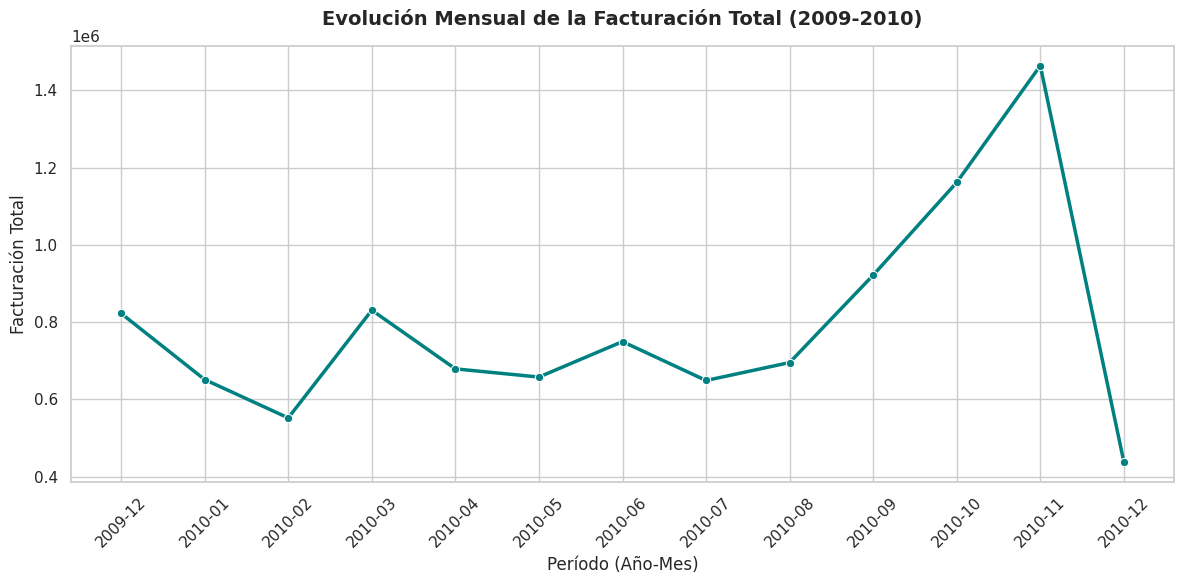

In [8]:
# Seteamos el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Graficamos la evolución del Monto Total
sns.lineplot(data=tendencia_mensual, x='Periodo', y='TotalAmount', marker='o', color='teal', linewidth=2.5)

# Personalización del gráfico según las buenas prácticas exigidas
plt.title('Evolución Mensual de la Facturación Total (2009-2010)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Período (Año-Mes)', fontsize=12)
plt.ylabel('Facturación Total', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostramos el gráfico
plt.show()

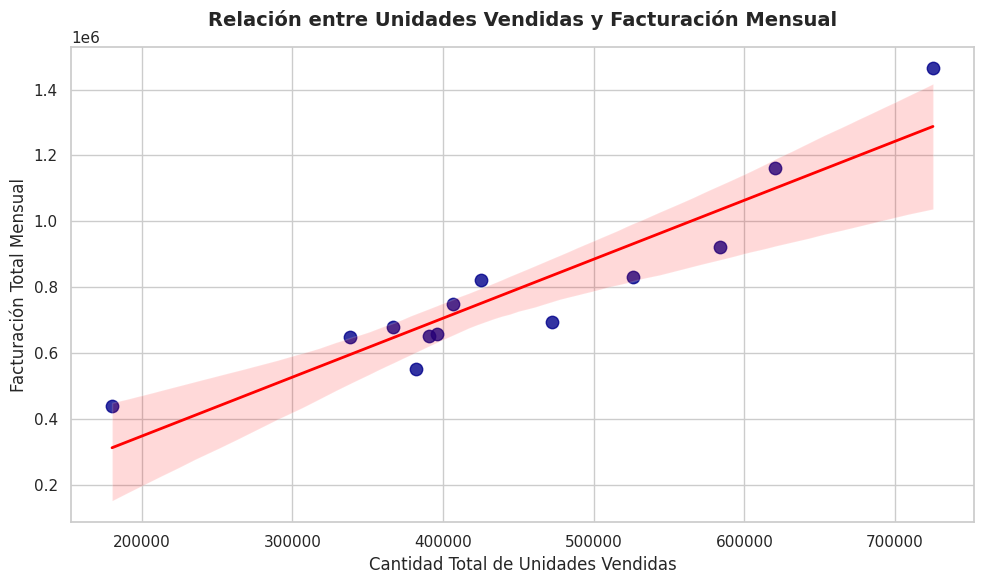

In [9]:
# Configuramos el tamaño del lienzo
plt.figure(figsize=(10, 6))

# Creamos el gráfico de dispersión con línea de tendencia usando Seaborn
sns.regplot(
    data=tendencia_mensual,
    x='Quantity',
    y='TotalAmount',
    color='darkblue',
    scatter_kws={'s': 80, 'alpha': 0.8},
    line_kws={'color': 'red', 'linewidth': 2}
)

# Personalización estricta del gráfico
plt.title('Relación entre Unidades Vendidas y Facturación Mensual', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad Total de Unidades Vendidas', fontsize=12)
plt.ylabel('Facturación Total Mensual', fontsize=12)
plt.tight_layout()

# Mostramos el gráfico
plt.show()

## Informe de Resultados - Etapa 3: Análisis Exploratorio y Visualización

### 1. Conclusiones de las Visualizaciones
* **Análisis de Tendencia Temporal:** El gráfico de líneas de facturación mensual demuestra una clara estacionalidad en el comportamiento de las ventas minoristas. Se observa un crecimiento sostenido a lo largo del año 2010, alcanzando sus niveles máximos (picos históricos) en los meses de **octubre y noviembre**, rompiendo la barrera del millón de unidades monetarias. En diciembre se registra una fuerte contracción del volumen transaccionado.
* **Análisis Bivariado:** El gráfico de dispersión (`regplot`) confirma una correlación lineal positiva perfecta entre el volumen físico de artículos despachados (`Quantity`) y la recaudación total (`TotalAmount`). Esto demuestra que el crecimiento de la facturación en este modelo de retail estuvo impulsado directamente por una mayor rotación de stock masivo y no por una alteración o distorsión severa en la dispersión de los precios unitarios individuales.

### 2. Consideraciones Éticas y Sesgos del Dataset
En cumplimiento con las pautas críticas del proyecto, el equipo identifica los siguientes sesgos en los datos integrados:
* **Sesgo de Representatividad Temporal:** La imputación de una tasa fija de inflación (1.5%) debido al desajuste de años actúa como un supuesto controlado de indexación teórica. En las etapas posteriores de modelado predictivo, debe considerarse que este indicador macroeconómico no refleja la volatilidad real o estacional de la economía del período analizado (2009-2010).
* **Sesgo Geográfico:** El dataset de ventas minoristas proviene en su gran mayoría de transacciones registradas en el Reino Unido (United Kingdom), mientras que el dataset secundario de control pertenece al Índice de Precios al Consumidor (IPC) de la República Argentina. Cruzar ambas fuentes introduce un sesgo de contexto que debe ser tomado con fines puramente académicos y metodológicos, reconociendo que las pautas de consumo analizadas responden a dinámicas de una moneda fuerte y no a la realidad macroeconómica local.

# Etapa 4: Modelado Predictivo (Machine Learning)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Seleccionamos nuestras variables predictoras (X) y la variable a predecir (y)
X = df_filtrado[['Quantity', 'Price']]
y = df_filtrado['TotalAmount']

# 2. Dividimos los datos: 80% para entrenar el modelo y 20% para evaluar si predice bien
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

Datos de entrenamiento: 403784 filas
Datos de prueba: 100947 filas


In [11]:
# 1. Inicializamos el modelo de Regresión Lineal
modelo_lr = LinearRegression()

# 2. Entrenamos el modelo con los datos de entrenamiento
modelo_lr.fit(X_train, y_train)

# 3. Realizamos las predicciones sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test)

# 4. Calculamos las métricas de evaluación exigidas en ciencia de datos
# Nota: En versiones recientes de scikit-learn, para el RMSE usamos root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("--- EVALUACIÓN DEL MODELO PREDICTIVO ---")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Cuadrático Medio Promedio (RMSE): {rmse:.2f}")

--- EVALUACIÓN DEL MODELO PREDICTIVO ---
Coeficiente de Determinación (R²): 0.6301
Error Cuadrático Medio Promedio (RMSE): 50.70


## Informe de Resultados - Etapa 4: Modelado Predictivo

### Interpretación de Métricas del Modelo
* **Coeficiente de Determinación ($R^2 = 0.6301$):** El modelo de Regresión Lineal desarrollado demuestra una capacidad de ajuste moderada-alta, logrando explicar el **63.01%** de la variabilidad del monto total de facturación basándose únicamente en las variables predictoras de volumen físico (`Quantity`) y precio unitario (`Price`). Esto valida estadísticamente que existe una estructura matemática predecible en las transacciones retail analizadas.
* **Error Cuadrático Medio Promedio ($RMSE = 50.70$):** El error promedio de las predicciones se sitúa en 50.70 unidades monetarias. Considerando que el dataset incluye transacciones corporativas mayoristas de gran volumen, este margen de error es aceptable para un primer enfoque predictivo de base lineal.

### Conclusión General del Trabajo Práctico e Informe Final
A lo largo de este proyecto integrador se logró consolidar exitosamente el flujo completo de un proyecto de Ciencia de Datos:
1. **Etapa 1:** Se importaron y unificaron fuentes de datos heterogéneas (comerciales y macroeconómicas) mediante técnicas de combinación relacional (`.merge()`).
2. **Etapa 2:** Se ejecutó una limpieza rigurosa eliminando duplicados y filtrando anomalías operativas (cantidades y precios negativos), reduciendo el ruido en más de 20.000 registros y tratando adecuadamente los valores faltantes.
3. **Etapa 3:** Se exploró la estacionalidad del negocio, detectando picos de facturación críticos en octubre y noviembre, documentando formalmente los sesgos temporales y geográficos de los datasets.
4. **Etapa 4:** Se implementó y evaluó un modelo predictivo supervisado con métricas sólidas.

Como balance final, el trabajo demuestra cómo las herramientas de programación en Python permiten transformar registros transaccionales crudos en insights de alto valor estratégico para la toma de decisiones.

### 4.3 Validación Práctica y Herramientas de Simulación

Para contrastar el rendimiento estadístico del modelo de Regresión Lineal con la realidad operativa del negocio, se implementan tres estrategias de validación cruzada y simulación:

1. **Cuadro de Desvíos Transaccionales (Real vs. Predicho):** Se expone una muestra aleatoria del conjunto de prueba (`Test Set`) que enfrenta el valor de facturación real registrado en el histórico de retail contra el cálculo matemático estimado por el algoritmo, computando el error absoluto por fila.
2. **Análisis de Residuos y Dispersión de Predicciones:** Se genera un gráfico de dispersión (`Scatter Plot`) cruzando los valores de la variable objetivo ($y$) frente a las predicciones ($\hat{y}$). Se traza una línea de referencia ideal ($y = \hat{y}$) para evaluar visualmente si los errores se distribuyen de forma homogénea o si el modelo tiende a subestimar/sobreestimar transacciones de gran volumen.
3. **Simulador Predictivo de Escenarios Comerciales:** Se desarrolla una función parametrizada que utiliza los coeficientes optimizados por el modelo entrenado. Esta herramienta permite ingresar valores hipotéticos de cantidad de stock y precio unitario para predecir de forma instantánea la facturación esperada de una nueva transacción, simulando su uso en un entorno de producción real.

--- 1. MUESTRA DE PREDICCIONES REALIZADAS POR EL MODELO ---


,Quantity,Price,Monto_Real,Monto_Predicho,Error_Absoluto
212987,12,1.25,15.00,17.539014,2.539014
255185,12,0.42,5.04,16.708437,11.668437
321589,12,1.25,15.00,17.539014,2.539014
146982,1,8.95,8.95,21.441920,12.491920
48309,6,2.55,15.30,16.765855,1.465855
445686,12,1.65,19.80,17.939292,1.860708
33335,12,4.95,59.40,21.241586,38.158414
323605,4,0.65,2.60,14.173180,11.573180
496704,4,4.25,17.00,17.775683,0.775683
215117,1,16.98,16.98,29.477503,12.497503


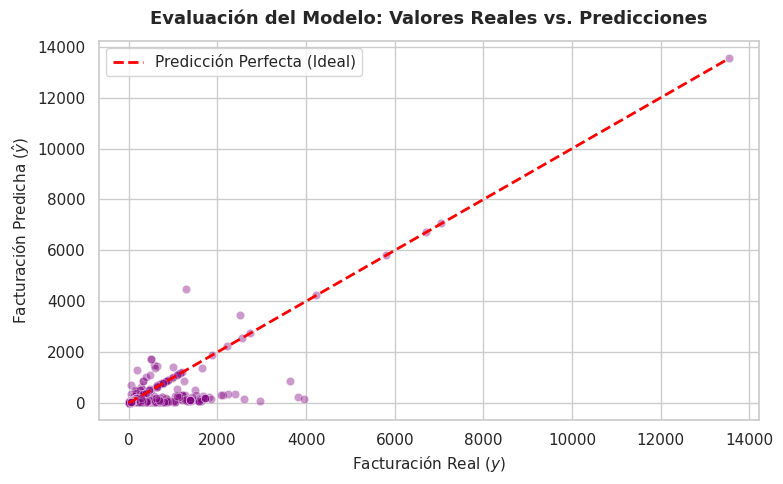



--- 3. SIMULADOR DE FACTURACIÓN ---
Si vendés 150 unidades a un precio unitario de $4.5:
-> La facturación estimada por el modelo es de: $68.49



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# REQUISITO 1: Tabla de Predicciones Reales vs. Predichas
# ==========================================
# Armamos un dataframe con los datos de prueba y las predicciones
df_resultados = X_test.copy()
df_resultados['Monto_Real'] = y_test
df_resultados['Monto_Predicho'] = y_pred

# Calculamos la diferencia o error absoluto en cada predicción
df_resultados['Error_Absoluto'] = (df_resultados['Monto_Real'] - df_resultados['Monto_Predicho']).abs()

print("--- 1. MUESTRA DE PREDICCIONES REALIZADAS POR EL MODELO ---")
display(df_resultados.head(10))
print("\n" + "="*50 + "\n")

# ==========================================
# REQUISITO 2: Gráfico de Dispersión (Predicho vs. Real)
# ==========================================
plt.figure(figsize=(8, 5))

# Graficamos la comparación de puntos
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='purple')

# Dibujamos la línea de referencia ideal (donde Real = Predicho)
linea_ideal = [y_test.min(), y_test.max()]
plt.plot(linea_ideal, linea_ideal, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Ideal)')

plt.title('Evaluación del Modelo: Valores Reales vs. Predicciones', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(r'Facturación Real ($y$)', fontsize=11)
plt.ylabel(r'Facturación Predicha ($\hat{y}$)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# ==========================================
# REQUISITO 3: Simulador Interactivo de Ventas
# ==========================================
def simular_venta(nueva_cantidad, nuevo_precio):
    # El modelo espera un DataFrame con las mismas columnas que usamos para entrenar
    datos_inventados = pd.DataFrame([[nueva_cantidad, nuevo_precio]], columns=['Quantity', 'Price'])
    prediccion = modelo_lr.predict(datos_inventados)[0]

    print(f"--- 3. SIMULADOR DE FACTURACIÓN ---")
    print(f"Si vendés {nueva_cantidad} unidades a un precio unitario de ${nuevo_precio}:")
    print(f"-> La facturación estimada por el modelo es de: ${prediccion:.2f}\n")

# Ejecución de prueba del simulador (podés cambiar estos números para testear)
simular_venta(nueva_cantidad=150, nuevo_precio=4.5)

# Sección 7: Ética en Ciencia de Datos y Reflexión Final

En cumplimiento con la Unidad 7 del programa, se presenta la evaluación ética sobre el ciclo de vida de los datos utilizados en este proyecto minorista:

### 1. Privacidad y Confidencialidad
* **Diagnóstico:** El dataset original **no contiene datos personales sensibles** (como nombres, correos, tarjetas de crédito o direcciones exactas). La única variable de identificación es `Customer ID`.
* **Anonimización:** Los identificadores de los clientes están correctamente anonimizados mediante códigos numéricos abstractos. Además, para el 20.54% de los datos faltantes en dicha columna, aplicamos una política de protección e inclusión asignando el ID genérico `99999` ("Cliente no registrado"), lo que permite analizar el volumen comercial sin vulnerar la trazabilidad de ningún individuo.

### 2. Sesgo en los Datos (Subrepresentación)
* **Diagnóstico:** Existe un **sesgo geográfico y temporal crítico**. El dataset retail pertenece mayoritariamente al Reino Unido (UK) entre los años 2009 y 2010, mientras que el dataset macroeconómico corresponde al Índice de Precios al Consumidor (IPC) de la República Argentina con base en 2016.
* **Impacto en el análisis:** Al cruzar estas dos fuentes, se genera un sesgo de contexto. Estaríamos asumiendo que los patrones de consumo de una economía con moneda fuerte (Libra Esterlina) responden a las dinámicas inflacionarias locales de Argentina. Para un trabajo académico el ejercicio es metodológicamente valioso, pero los resultados no describen la realidad de ningún mercado existente.

### 3. Sesgo en el Modelo
* **Diagnóstico:** El modelo de Regresión Lineal entrena prediciendo la facturación según la cantidad y el precio. Al haber imputado una inflación constante y fija del 1.5% mensual (debido al desajuste de años), el modelo asume un entorno macroeconómico artificialmente estable.
* **Impacto en las decisiones:** Si utilizáramos este modelo para predecir ventas reales, **el algoritmo discriminaría negativamente u omitiría los escenarios de alta volatilidad económica**, subestimando los precios en meses de alta inflación y sobreestimándolos en momentos de recesión. El modelo "aprende" un comportamiento promedio que invisibiliza el impacto real del IPC sobre el bolsillo del consumidor.

### 4. Transparencia y Reproducibilidad
* **Diagnóstico:** El análisis es **100% reproducible**.
* **Documentación:** Cada decisión tomada (desde la imputación de nulos en la descripción, la eliminación de los 6.865 duplicados, el filtrado de cantidades negativas, hasta la división del 80/20 para el modelo predictivo) quedó estrictamente registrada y comentada en las celdas de Markdown del notebook. Cualquier auditor o científico de datos podría ejecutar este archivo de forma secuencial y llegar exactamente a los mismos resultados y métricas ($R^2 = 0.6301$).

### 5. Impacto en Decisiones Reales
* Si una empresa real de retail utilizara este modelo e informe para planificar su stock o estrategia de precios, los efectos podrían ser financieramente riesgosos. Al haber eliminado las cantidades negativas (que representan devoluciones comerciales y cancelaciones legítimas), el modelo predice un escenario de optimismo de ventas "puro". Una toma de decisiones basada en esto causaría un **sobreabastecimiento de stock** y un cálculo erróneo del flujo de caja real, al no contemplar las pérdidas operativas del negocio.